# SMS Spam Detection: A Comparative NLP Study

---

## Overview

This notebook implements and compares five NLP models on binary SMS spam classification (spam / ham), using the UCI SMS Spam Collection dataset.

### Models
| # | Model | Type | Reference |
|---|-------|------|-----------|
| 1 | **SVM** | Traditional ML | [6] Yang et al., 2007 |
| 2 | **TextCNN** | Deep Learning | [5] Kim, 2014 |
| 3 | **Bi-GRU** | Deep Learning | GloVe embeddings: [4] Pennington et al., 2014 |
| 4 | **DistilBERT** | Transformer | [1] Sanh et al., 2019 |
| 5 | **RoBERTa** | Transformer | [2] Liu et al., 2019 |

### Dataset
- **Source**: UCI Machine Learning Repository — SMS Spam Collection
- **Total**: 5,572 English SMS messages | **Spam**: 747 (~13.4%) | **Ham**: 4,825 (~86.6%)

### Three Core Challenges
1. **Short text length** — sparse signals; addressed via contextual embeddings [1,2,3] and GloVe dense vectors [4]
2. **Informal language** — abbreviations/typos; subword tokenisation [1,2] and n-gram CNN filters [5] complement each other
3. **Class imbalance** — ~13% spam; addressed via weighted cross-entropy and SVM class weighting [6]

### Data Split Strategy
- **Stratified 80/20 train-test split** — preserves class distribution in both partitions
- **Internal 10% validation** drawn from the training set — used only for early stopping and model selection; test set is never seen during training

### Evaluation Metrics
- **MCC** — Matthews Correlation Coefficient (robust to class imbalance)
- **PR-AUC** — Area Under the Precision-Recall Curve
- **F1-Score** — harmonic mean of precision and recall (spam class)

### References
[1] Sanh et al., DistilBERT, arXiv:1910.01108, 2019.  
[2] Liu et al., RoBERTa, arXiv:1907.11692, 2019.  
[3] Devlin et al., BERT, NAACL-HLT 2019.  
[4] Pennington et al., GloVe, EMNLP 2014.  
[5] Kim, TextCNN, EMNLP 2014.  
[6] Yang et al., Weighted SVM, IJPRAI 2007.

---
## Section 1 — Environment Setup

Install all required packages and configure global settings. GPU / MPS is auto-detected — transformer models (DistilBERT [1], RoBERTa [2]) benefit significantly from GPU acceleration.

> **GloVe embeddings (optional):** Download `glove.6B.zip` from https://nlp.stanford.edu/projects/glove/, extract `glove.6B.100d.txt` into a `data/` folder. If absent, Bi-GRU and TextCNN fall back to random initialisations.

In [ ]:
import subprocess, sys
subprocess.run([
    sys.executable, "-m", "pip", "install", "-q",
    "numpy", "pandas", "scikit-learn",
    "torch", "transformers",
    "matplotlib", "seaborn", "tqdm", "nltk", "requests"
], check=True)
print("Installation complete.")

Installation complete.


In [ ]:
# ── Standard library ──────────────────────────────────────────────────────────
import os, re, copy, json, zipfile, warnings, time, pickle
import requests
from collections import Counter
warnings.filterwarnings("ignore")

# ── Numerical & data ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
%matplotlib inline
plt.rcParams.update({"figure.dpi": 120})

# ── NLP / NLTK ────────────────────────────────────────────────────────────────
import nltk
nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords

# ── Scikit-learn ──────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    matthews_corrcoef, f1_score, average_precision_score,
    precision_recall_curve, confusion_matrix, classification_report
)

# ── PyTorch ───────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm.notebook import tqdm

# ── HuggingFace Transformers ──────────────────────────────────────────────────
from transformers import AutoTokenizer, DistilBertModel, RobertaModel

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Global constants ──────────────────────────────────────────────────────────
DATA_DIR        = "data"
RESULTS_DIR     = "results"
GLOVE_PATH      = os.path.join(DATA_DIR, "glove.6B.100d.txt")
MAX_VOCAB       = 20_000
MAX_SEQ_LEN     = 128
TRANSFORMER_LEN = 128
TEST_SIZE       = 0.20          # 80/20 split (proposal spec)
VAL_FRAC        = 0.10          # 10% of train → internal validation
STOP_WORDS      = set(stopwords.words("english"))
PALETTE = {
    "SVM":"#4C6EF5", "TextCNN":"#F76707",
    "Bi-GRU":"#2F9E44", "DistilBERT":"#AE3EC9", "RoBERTa":"#E03131"
}

os.makedirs(DATA_DIR,    exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# ── Device detection ──────────────────────────────────────────────────────────
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print(f"  PyTorch : {torch.__version__}")
print(f"  Device  : {DEVICE}")
print("  All imports successful.")

  PyTorch : 2.10.0+cu128
  Device  : cuda
  All imports successful.


---
## Section 2 — Dataset Loading & Exploratory Data Analysis

The **UCI SMS Spam Collection** is auto-downloaded from the UCI ML Repository. It contains 5,572 English SMS messages labelled `ham` or `spam`.

EDA examines:
- **Class distribution** — confirms the ~13.4% spam imbalance that motivates weighted training strategies
- **Message length** — spam messages tend to be longer (more promotional content)
- **Sample messages** — illustrates informal language, abbreviations, and spam patterns

In [ ]:
# ── Download and load dataset ─────────────────────────────────────────────────
UCI_URL  = ("https://archive.ics.uci.edu/ml/machine-learning-databases"
            "/00228/smsspamcollection.zip")
RAW_FILE = os.path.join(DATA_DIR, "SMSSpamCollection")

def download_dataset():
    if os.path.exists(RAW_FILE):
        print(f"Dataset present: {RAW_FILE}")
        return
    print("Downloading UCI SMS Spam Collection ...")
    zip_path = os.path.join(DATA_DIR, "tmp.zip")
    r = requests.get(UCI_URL, timeout=30)
    r.raise_for_status()
    with open(zip_path, "wb") as f:
        f.write(r.content)
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(DATA_DIR)
    os.remove(zip_path)
    print(f"Saved to: {RAW_FILE}")

download_dataset()

df = pd.read_csv(
    RAW_FILE, sep="\t", header=None,
    names=["label", "text"], encoding="latin-1"
)
df["label_int"]  = (df["label"] == "spam").astype(int)
df["char_count"] = df["text"].str.len()
df["word_count"] = df["text"].str.split().str.len()

spam = df["label_int"].sum()
ham  = (df["label_int"] == 0).sum()
print(f"\nTotal   : {len(df):,}")
print(f"Spam    : {spam:,}  ({spam/len(df)*100:.1f}%)")
print(f"Ham     : {ham:,}  ({ham/len(df)*100:.1f}%)")
df.head(6)

Saved to: data/SMSSpamCollection

Total   : 5,572
Spam    : 747  (13.4%)
Ham     : 4,825  (86.6%)


,label,text,label_int,char_count,word_count
0,ham,"Go until jurong point, crazy.. Available only ...",0,111,20
1,ham,Ok lar... Joking wif u oni...,0,29,6
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1,155,28
3,ham,U dun say so early hor... U c already then say...,0,49,11
4,ham,"Nah I don't think he goes to usf, he lives aro...",0,61,13
5,spam,FreeMsg Hey there darling it's been 3 week's n...,1,148,32


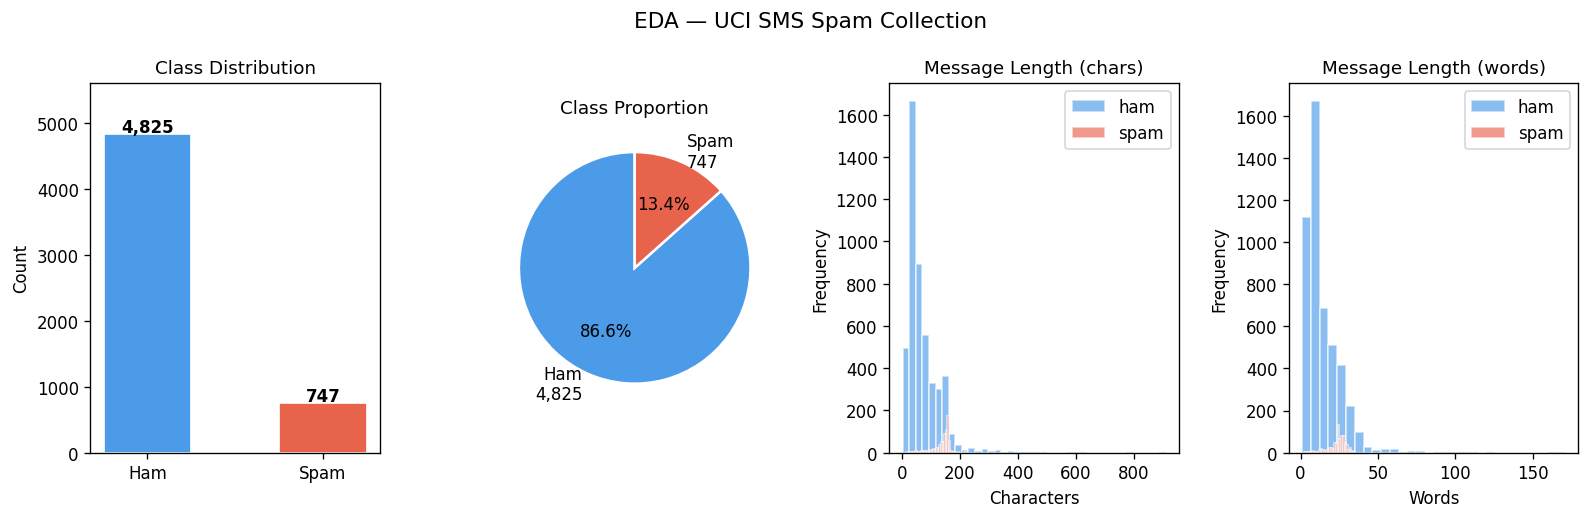

In [ ]:
# ── Exploratory visualisation ─────────────────────────────────────────────────
COLORS = {"ham": "#4C9BE8", "spam": "#E8634C"}
counts = df["label"].value_counts()

fig = plt.figure(figsize=(16, 4))
gs  = gridspec.GridSpec(1, 4, figure=fig, wspace=0.38)
ax0, ax1, ax2, ax3 = [fig.add_subplot(gs[i]) for i in range(4)]

# Class count
bars = ax0.bar(["Ham", "Spam"], [counts["ham"], counts["spam"]],
               color=[COLORS["ham"], COLORS["spam"]], width=0.5, edgecolor="white")
for b in bars:
    ax0.text(b.get_x()+b.get_width()/2, b.get_height()+40,
             f"{int(b.get_height()):,}", ha="center", fontsize=10, fontweight="bold")
ax0.set_title("Class Distribution", fontsize=11)
ax0.set_ylabel("Count"); ax0.set_ylim(0, 5600)

# Proportion pie
ax1.pie([counts["ham"], counts["spam"]],
        labels=[f"Ham\n{counts['ham']:,}", f"Spam\n{counts['spam']}"],
        colors=[COLORS["ham"], COLORS["spam"]],
        autopct="%1.1f%%", startangle=90,
        wedgeprops=dict(edgecolor="white", linewidth=1.5))
ax1.set_title("Class Proportion", fontsize=11)

# Character length distribution
for lbl, c in COLORS.items():
    ax2.hist(df[df["label"]==lbl]["char_count"], bins=40,
             alpha=0.65, label=lbl, color=c, edgecolor="white")
ax2.set_title("Message Length (chars)", fontsize=11)
ax2.set_xlabel("Characters"); ax2.set_ylabel("Frequency"); ax2.legend()

# Word count distribution
for lbl, c in COLORS.items():
    ax3.hist(df[df["label"]==lbl]["word_count"], bins=30,
             alpha=0.65, label=lbl, color=c, edgecolor="white")
ax3.set_title("Message Length (words)", fontsize=11)
ax3.set_xlabel("Words"); ax3.set_ylabel("Frequency"); ax3.legend()

fig.suptitle("EDA — UCI SMS Spam Collection", fontsize=13, y=1.03)
plt.savefig(os.path.join(RESULTS_DIR, "01_eda.png"), dpi=120, bbox_inches="tight")
plt.show()

In [ ]:
# ── Descriptive statistics and sample messages ────────────────────────────────
print("Descriptive statistics:")
print(df.groupby("label")[["char_count","word_count"]].describe().round(1).to_string())

print("\n── Sample HAM messages ──")
for msg in df[df["label"]=="ham"]["text"].sample(3, random_state=SEED).values:
    print(f"  [{len(msg):3d} chars]  {msg[:95]}")

print("\n── Sample SPAM messages ──")
for msg in df[df["label"]=="spam"]["text"].sample(3, random_state=SEED).values:
    print(f"  [{len(msg):3d} chars]  {msg[:95]}")

Descriptive statistics:
      char_count                                                word_count                                          
           count   mean   std   min    25%    50%    75%    max      count  mean   std  min   25%   50%   75%    max
label                                                                                                               
ham       4825.0   71.6  58.5   2.0   33.0   52.0   93.0  910.0     4825.0  14.3  11.5  1.0   7.0  11.0  19.0  171.0
spam       747.0  139.1  29.0  13.0  133.0  149.0  158.0  224.0      747.0  23.9   5.8  2.0  22.0  25.0  28.0   35.0

── Sample HAM messages ──
  [ 86 chars]  If i not meeting Ã¼ all rite then i'll go home lor. If Ã¼ dun feel like comin it's ok.
  [103 chars]  I.ll always be there, even if its just in spirit. I.ll get a bb soon. Just trying to be sure i 
  [ 32 chars]  Sorry that took so long, omw now

── Sample SPAM messages ──
  [159 chars]  Summers finally here! Fancy a chat or flirt with sexy single

---
## Section 3 — Text Preprocessing

A lightweight, **model-agnostic** cleaning pipeline is applied uniformly before any model-specific tokenisation.

| Step | Operation | Rationale |
|------|-----------|----------|
| 1 | Lowercase | Normalise case |
| 2 | URLs → `url` | Preserve signal, remove domain noise |
| 3 | Emails → `email` | Preserve signal |
| 4 | 10+ digit strings → `phone` | Common spam indicator |
| 5 | Remove non-alphanumeric | Strip punctuation/symbols |
| 6 | Collapse whitespace | Clean spacing |
| 7 | *(SVM only)* Remove stopwords | Reduce TF-IDF noise |

> Transformer models (DistilBERT [1], RoBERTa [2]) apply their own subword tokenisers on top of this cleaned text. While subword tokenisation can improve robustness to misspellings and rare words [1, 2], its effectiveness on highly abbreviated SMS language is an empirical question examined in this study. TextCNN [5] complements this by capturing n-gram surface patterns directly.

In [ ]:
def clean_text(text: str, remove_stopwords: bool = False) -> str:
    """
    Universal text cleaning pipeline.
    Steps 1-6 applied to all models.
    Step 7 (stopword removal) used only for SVM TF-IDF pipeline.
    """
    text = text.lower()
    text = re.sub(r"http\S+|www\S+",  " url ",   text)   # step 2
    text = re.sub(r"\S+@\S+",          " email ", text)   # step 3
    text = re.sub(r"\b\d{10,}\b",      " phone ", text)   # step 4
    text = re.sub(r"[^a-z0-9\s]",      " ",       text)   # step 5
    text = re.sub(r"\s+",              " ",       text).strip()  # step 6
    if remove_stopwords:                                   # step 7
        text = " ".join(w for w in text.split() if w not in STOP_WORDS)
    return text


# ── Demonstration ─────────────────────────────────────────────────────────────
demo = [
    "FREE entry in 2 a wkly comp to win FA Cup tkts! Text FA to 87121 to receive",
    "Ok lar... Joking wif u oni...",
    "WINNER!! Selected 2 receivea prize! Call 09061701461 or visit www.win.co.uk",
]
print(f"{'Original (truncated)':<55}  {'Cleaned':<55}")
print("-" * 112)
for ex in demo:
    print(f"{ex[:53]:<55}  {clean_text(ex)[:53]:<55}")

df["text_clean"] = df["text"].apply(clean_text)
print("\nCleaned text column added to DataFrame.")

Original (truncated)                                     Cleaned                                                
----------------------------------------------------------------------------------------------------------------
FREE entry in 2 a wkly comp to win FA Cup tkts! Text     free entry in 2 a wkly comp to win fa cup tkts text f  
Ok lar... Joking wif u oni...                            ok lar joking wif u oni                                
WINNER!! Selected 2 receivea prize! Call 09061701461     winner selected 2 receivea prize call phone or visit   

Cleaned text column added to DataFrame.


---
## Section 4 — Data Splitting & Shared Utilities

### Split Strategy (per proposal)
```
Full dataset (5,572)
   ├── Test set    : 20%  (1,115 messages) ← held out, never used during training
   └── Train+Val  : 80%  (4,457 messages)
            ├── Train   : 90% of 80% = 72% overall (4,011 messages)
            └── Val     : 10% of 80% =  8% overall (446 messages)  ← internal only
```
All splits are **stratified** to preserve the ~13.4% spam ratio.

### Three Feature Pipelines
| Pipeline | Models | Representation |
|----------|--------|----------------|
| TF-IDF (1–2 gram, 10k features) | SVM [6] | Sparse matrix |
| Vocab index + GloVe-100d [4] | TextCNN [5], Bi-GRU | Integer sequences |
| Subword tokenisation | DistilBERT [1], RoBERTa [2] | Token IDs + attention mask |

### Class Imbalance
$$w_c = \frac{N}{K \cdot n_c}$$
where $N$ = total training samples, $K$ = number of classes, $n_c$ = class count.  
Gives spam ~6.5× the weight of ham during training.

In [ ]:
# ── Stratified 80/20 train-test split ─────────────────────────────────────────
train_val_df, test_df = train_test_split(
    df, test_size=TEST_SIZE,
    stratify=df["label_int"], random_state=SEED
)
# ── Internal 10% validation from training set ─────────────────────────────────
train_df, val_df = train_test_split(
    train_val_df, test_size=VAL_FRAC,
    stratify=train_val_df["label_int"], random_state=SEED
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

y_train = train_df["label_int"].values
y_val   = val_df["label_int"].values
y_test  = test_df["label_int"].values

for name, part, y in [("Train (72%)", train_df, y_train),
                      ("Val   ( 8%)", val_df,   y_val),
                      ("Test  (20%)", test_df,  y_test)]:
    print(f"  {name}: {len(part):>5} msgs | "
          f"spam={y.sum():>3} ({y.mean()*100:.1f}%) | "
          f"ham={(y==0).sum():>4}")

  Train (72%):  4011 msgs | spam=538 (13.4%) | ham=3473
  Val   ( 8%):   446 msgs | spam= 60 (13.5%) | ham= 386
  Test  (20%):  1115 msgs | spam=149 (13.4%) | ham= 966


In [ ]:
# ── TF-IDF pipeline (SVM [6]) ─────────────────────────────────────────────────
#
# ngram_range=(1,2) : unigrams + bigrams capture "free entry", "win prize"
# max_features=10000: top 10,000 n-gram features
# sublinear_tf=True : replace raw TF with 1+log(TF) to dampen frequent terms
#
# Vectoriser fit on training set ONLY — prevents leakage into val/test.
# Stopwords removed for SVM to reduce noise in high-dimensional TF-IDF space.

tfidf = TfidfVectorizer(max_features=10_000, ngram_range=(1,2), sublinear_tf=True)

X_train_tfidf = tfidf.fit_transform(
    train_df["text"].apply(lambda t: clean_text(t, remove_stopwords=True))
)
X_val_tfidf   = tfidf.transform(
    val_df["text"].apply(lambda t: clean_text(t, remove_stopwords=True))
)
X_test_tfidf  = tfidf.transform(
    test_df["text"].apply(lambda t: clean_text(t, remove_stopwords=True))
)

print(f"TF-IDF  train={X_train_tfidf.shape}  "
      f"val={X_val_tfidf.shape}  test={X_test_tfidf.shape}")

TF-IDF  train=(4011, 10000)  val=(446, 10000)  test=(1115, 10000)


In [ ]:
# ── Vocabulary for TextCNN [5] and Bi-GRU ────────────────────────────────────
#
# index 0 → <PAD>  (padding token; embedding zeroed out)
# index 1 → <UNK>  (out-of-vocabulary words)
# Built from training corpus only.

class Vocabulary:
    PAD = "<PAD>"
    UNK = "<UNK>"

    def __init__(self, max_size=MAX_VOCAB):
        self.max_size = max_size
        self.word2idx = {self.PAD: 0, self.UNK: 1}
        self.idx2word = {0: self.PAD, 1: self.UNK}

    def build(self, texts):
        counts = Counter(w for t in texts for w in t.split())
        for word, _ in counts.most_common(self.max_size - 2):
            idx = len(self.word2idx)
            self.word2idx[word] = idx
            self.idx2word[idx]  = word
        print(f"  Vocabulary: {len(self.word2idx):,} tokens")
        return self

    def encode(self, text, max_len=MAX_SEQ_LEN):
        tokens = text.split()[:max_len]
        ids    = [self.word2idx.get(w, 1) for w in tokens]
        ids   += [0] * (max_len - len(ids))   # pad
        return ids

    def __len__(self): return len(self.word2idx)


vocab = Vocabulary().build([clean_text(t) for t in train_df["text"].tolist()])

  Vocabulary: 7,017 tokens


In [ ]:
# ── GloVe-100d embedding loader [4] ──────────────────────────────────────────
#
# GloVe (Pennington et al., 2014) [4] maps vocabulary words to 100-dimensional
# dense vectors trained on 6B tokens. This reduces sparsity by placing
# semantically similar words ("free", "win", "prize") near each other.
# OOV words get small random vectors; <PAD> is fixed at zero.

def load_glove(vocab, path, embed_dim=100):
    emb = np.random.normal(scale=0.1, size=(len(vocab), embed_dim)).astype(np.float32)
    emb[0] = 0.0   # PAD → zero
    if not os.path.exists(path):
        print(f"  [WARNING] GloVe not found at {path}. Using random initialisation.")
        return emb
    loaded = 0
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.rstrip().split()
            if parts[0] in vocab.word2idx:
                emb[vocab.word2idx[parts[0]]] = np.array(parts[1:], dtype=np.float32)
                loaded += 1
    print(f"  GloVe [4]: {loaded}/{len(vocab):,} tokens "
          f"({loaded/len(vocab)*100:.1f}% coverage)")
    return emb


GLOVE_EMB = load_glove(vocab, GLOVE_PATH)

  GloVe [4]: 5592/7,017 tokens (79.7% coverage)


In [ ]:
# ── PyTorch Dataset wrappers ──────────────────────────────────────────────────

class SMSDataset(Dataset):
    """Vocab-indexed dataset for TextCNN [5] and Bi-GRU."""
    def __init__(self, texts, labels, vocab, max_len=MAX_SEQ_LEN):
        self.inputs = [
            torch.tensor(vocab.encode(clean_text(t), max_len), dtype=torch.long)
            for t in texts
        ]
        self.labels = torch.tensor(labels, dtype=torch.long)
    def __len__(self):           return len(self.labels)
    def __getitem__(self, idx):  return self.inputs[idx], self.labels[idx]


class TransformerSMSDataset(Dataset):
    """Subword-tokenised dataset for DistilBERT [1] and RoBERTa [2]."""
    def __init__(self, texts, labels, tokenizer, max_len=TRANSFORMER_LEN):
        self.encodings = tokenizer(
            list(texts), truncation=True, padding="max_length",
            max_length=max_len, return_tensors="pt"
        )
        self.labels = torch.tensor(list(labels), dtype=torch.long)
    def __len__(self):          return len(self.labels)
    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item["labels"] = self.labels[idx]
        return item


# ── Shared DataLoader factory ─────────────────────────────────────────────────
BATCH_SIZE = 64

def make_dl_loaders(train_df, val_df, test_df, vocab, batch_size=BATCH_SIZE):
    """DataLoaders for TextCNN / Bi-GRU."""
    def _ld(df_, shuffle):
        ds = SMSDataset(df_["text"].tolist(), df_["label_int"].tolist(), vocab)
        return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)
    return _ld(train_df, True), _ld(val_df, False), _ld(test_df, False)


def make_transformer_loaders(train_df, val_df, test_df,
                              tokenizer, batch_size=16):
    """DataLoaders for DistilBERT [1] / RoBERTa [2]."""
    def _ld(df_, shuffle):
        ds = TransformerSMSDataset(
            df_["text"].tolist(), df_["label_int"].tolist(), tokenizer
        )
        return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)
    return _ld(train_df, True), _ld(val_df, False), _ld(test_df, False)


# ── Inverse-frequency class weights ──────────────────────────────────────────
#   w_c = N / (K * n_c)
def compute_class_weights(labels):
    counts  = np.bincount(labels)
    weights = len(labels) / (len(counts) * counts)
    return torch.tensor(weights, dtype=torch.float).to(DEVICE)

CLASS_WEIGHTS = compute_class_weights(y_train)
print(f"Class weights — ham: {CLASS_WEIGHTS[0]:.4f}  |  "
      f"spam: {CLASS_WEIGHTS[1]:.4f}  "
      f"(spam weight is ~{CLASS_WEIGHTS[1]/CLASS_WEIGHTS[0]:.1f}x larger)")

Class weights — ham: 0.5775  |  spam: 3.7277  (spam weight is ~6.5x larger)


In [ ]:
# ── Shared PyTorch training loop ──────────────────────────────────────────────
#
# Features:
#   - Weighted cross-entropy loss  (addresses class imbalance)
#   - AdamW with weight decay      (regularisation)
#   - Gradient clipping (1.0)      (transformer stability)
#   - ReduceLROnPlateau on val F1  (adaptive learning rate)
#   - Early stopping on val F1     (prevents overfitting)
#   - Best checkpoint restored     (returns epoch with highest val F1)

def _forward(model, batch, is_transformer):
    """Unpack batch and run forward pass. Returns (logits, labels)."""
    if is_transformer:
        ids    = batch["input_ids"].to(DEVICE)
        mask   = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)
        logits = model(ids, attention_mask=mask)
    else:
        inputs, labels = batch
        logits = model(inputs.to(DEVICE))
        labels = labels.to(DEVICE)
    return logits, labels


def train_model(model, train_loader, val_loader,
                epochs=10, lr=1e-3, patience=3, is_transformer=False):
    model.to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS)
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=1e-2)
    scheduler = ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)

    best_f1, best_state, no_improve = -1.0, None, 0
    history = {"train_loss": [], "val_loss": [], "val_f1": []}

    for epoch in range(1, epochs + 1):
        # Training pass
        model.train()
        total, n = 0.0, 0
        for batch in tqdm(train_loader, desc=f"Epoch {epoch}/{epochs}", leave=False):
            optimizer.zero_grad()
            logits, labels = _forward(model, batch, is_transformer)
            loss = criterion(logits, labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total += loss.item(); n += 1

        # Validation pass
        val_loss, val_f1, _, _ = evaluate_model(model, val_loader,
                                                 criterion, is_transformer)
        scheduler.step(val_f1)
        avg = total / max(n, 1)
        history["train_loss"].append(avg)
        history["val_loss"].append(val_loss)
        history["val_f1"].append(val_f1)
        print(f"  Epoch {epoch:02d} | train_loss={avg:.4f} | "
              f"val_loss={val_loss:.4f} | val_F1={val_f1:.4f}")

        # Early stopping
        if val_f1 > best_f1:
            best_f1    = val_f1
            best_state = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"  Early stopping at epoch {epoch}.")
                break

    model.load_state_dict(best_state)
    print(f"  Best val F1 = {best_f1:.4f}")
    return model, history


def evaluate_model(model, loader, criterion, is_transformer=False):
    """Inference pass. Returns (avg_loss, f1, y_pred, y_prob)."""
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    total, n = 0.0, 0
    with torch.no_grad():
        for batch in loader:
            logits, labels = _forward(model, batch, is_transformer)
            total += criterion(logits, labels).item(); n += 1
            probs = torch.softmax(logits, -1)[:, 1].cpu().numpy()
            preds = logits.argmax(-1).cpu().numpy()
            all_probs.extend(probs); all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    return total/max(n,1), f1, np.array(all_preds), np.array(all_probs)


# ── Metric computation ────────────────────────────────────────────────────────
def compute_metrics(y_true, y_pred, y_prob=None, name=""):
    mcc    = matthews_corrcoef(y_true, y_pred)
    f1     = f1_score(y_true, y_pred, zero_division=0)
    pr_auc = average_precision_score(y_true, y_prob) if y_prob is not None else None
    if name: print(f"\n[{name} — Test Set]")
    print(f"  MCC    : {mcc:.4f}")
    print(f"  F1     : {f1:.4f}")
    if pr_auc: print(f"  PR-AUC : {pr_auc:.4f}")
    print(classification_report(y_true, y_pred,
                                target_names=["ham","spam"], zero_division=0))
    return {"mcc": mcc, "f1": f1, "pr_auc": pr_auc}


# Result store
ALL_RESULTS = {}
print("Shared utilities defined.")

Shared utilities defined.


---
## Section 5 — Model 1: SVM (Traditional ML Baseline)

### Motivation [6]
SVM is included as the **traditional ML baseline**. It supports `class_weight='balanced'`, which automatically scales the SVM penalty inversely with class frequency — directly addressing the 13.4% spam imbalance without requiring architectural changes. It also maximises the margin between classes, making it comparatively robust on high-dimensional sparse TF-IDF features.

### Architecture
```
Text  →  clean_text() + stopword removal
      →  TF-IDF (1–2 gram, 10,000 features, sublinear TF)
      →  LinearSVC (class_weight='balanced') [6]
      →  CalibratedClassifierCV (Platt scaling → probabilities for PR-AUC)
```

### Hyperparameter Tuning
5-fold cross-validated grid search over C ∈ {0.01, 0.1, 1.0, 10.0} on the **training set only**.

In [ ]:
print("=" * 55)
print("  MODEL 1: SVM (LinearSVC + TF-IDF)  [6]")
print("=" * 55)

base_svm = LinearSVC(class_weight="balanced", max_iter=5000, dual=True)
cal_svm  = CalibratedClassifierCV(base_svm, cv=3, method="sigmoid")

gs_svm = GridSearchCV(
    cal_svm,
    param_grid={"estimator__C": [0.01, 0.1, 1.0, 10.0]},
    cv=5, scoring="f1", n_jobs=-1, verbose=1
)
gs_svm.fit(X_train_tfidf, y_train)
svm_model = gs_svm.best_estimator_

print(f"\n  Best C   = {gs_svm.best_params_['estimator__C']}")
print(f"  CV F1    = {gs_svm.best_score_:.4f}")

# Validation check
print("\n  [SVM — Validation]")
svm_val_pred = svm_model.predict(X_val_tfidf)
svm_val_prob = svm_model.predict_proba(X_val_tfidf)[:, 1]
print(f"  Val F1   = {f1_score(y_val, svm_val_pred, zero_division=0):.4f}")

  MODEL 1: SVM (LinearSVC + TF-IDF)  [6]
Fitting 5 folds for each of 4 candidates, totalling 20 fits

  Best C   = 10.0
  CV F1    = 0.9292

  [SVM — Validation]
  Val F1   = 0.9483


In [ ]:
# ── SVM test evaluation ───────────────────────────────────────────────────────
svm_y_pred = svm_model.predict(X_test_tfidf)
svm_y_prob = svm_model.predict_proba(X_test_tfidf)[:, 1]
svm_metrics = compute_metrics(y_test, svm_y_pred, svm_y_prob, name="SVM")

ALL_RESULTS["SVM"] = {
    "metrics": svm_metrics, "y_true": y_test,
    "y_pred": svm_y_pred,   "y_prob": svm_y_prob
}
print("SVM results stored.")


[SVM — Test Set]
  MCC    : 0.9293
  F1     : 0.9384
  PR-AUC : 0.9717
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       966
        spam       0.96      0.92      0.94       149

    accuracy                           0.98      1115
   macro avg       0.97      0.96      0.96      1115
weighted avg       0.98      0.98      0.98      1115

SVM results stored.


---
## Section 6 — Model 2: TextCNN

### Motivation [5]
TextCNN (Kim, 2014) [5] captures **local n-gram patterns** via parallel convolutional filters of different widths. This is well-suited for spam detection because spam messages often contain distinctive surface-level cues: repeated exclamation marks, prize-related phrases, urgency keywords. While subword tokenisation in transformer models [1, 2] approaches informal language differently, TextCNN directly learns discriminative n-gram detectors from the training data.

### Architecture
```
Input (batch × 128) → Embedding (vocab × 100d, GloVe init [4])
  → Parallel Conv1d: kernel_size ∈ {2,3,4}, 128 filters each
  → ReLU + max-over-time pooling
  → Concat (384d) → Dropout(0.3) → FC(384 → 2)
```

In [ ]:
class TextCNN(nn.Module):
    """
    Kim (2014) [5] TextCNN.
    Each Conv1d filter acts as a learned n-gram detector.
    Parallel filters of widths 2–5 capture bigrams to 5-grams.
    GloVe [4] initialisation reduces sparsity from the start.
    """
    def __init__(self, vocab_size, embed_dim=100, num_classes=2,
                 num_filters=128, filter_sizes=None,
                 dropout=0.5, pretrained_emb=None, freeze_emb=False):
        super().__init__()
        if filter_sizes is None:
            filter_sizes = [2, 3, 4, 5]

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        if pretrained_emb is not None:
            self.embedding.weight = nn.Parameter(
                torch.tensor(pretrained_emb, dtype=torch.float),
                requires_grad=not freeze_emb
            )
        self.convs   = nn.ModuleList([
            nn.Conv1d(embed_dim, num_filters, kernel_size=k)
            for k in filter_sizes
        ])
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(num_filters * len(filter_sizes), num_classes)

    def forward(self, x):
        emb = self.embedding(x).permute(0, 2, 1)    # (B, E, L)
        pooled = []
        for conv in self.convs:
            h = F.relu(conv(emb))                    # (B, F, L-k+1)
            h = F.max_pool1d(h, h.size(2)).squeeze(2)  # (B, F)
            pooled.append(h)
        return self.fc(self.dropout(torch.cat(pooled, dim=1)))


print("TextCNN [5] architecture defined.")

TextCNN [5] architecture defined.


### NO TUNE VESION (can delete once confirm)

In [ ]:
print("=" * 55)
print("  MODEL 2: TextCNN  [5]")
print("=" * 55)

cnn_tr, cnn_val, cnn_te = make_dl_loaders(train_df, val_df, test_df, vocab)

textcnn = TextCNN(len(vocab), embed_dim=100, pretrained_emb=GLOVE_EMB)
print(f"  Parameters: {sum(p.numel() for p in textcnn.parameters()):,}")

textcnn, cnn_history = train_model(
    textcnn, cnn_tr, cnn_val,
    epochs=10, lr=1e-3, patience=3, is_transformer=False
)

  MODEL 2: TextCNN  [5]
  Parameters: 882,438


Epoch 1/10:   0%|          | 0/63 [00:00<?, ?it/s]

  Epoch 01 | train_loss=0.4767 | val_loss=0.2243 | val_F1=0.8682


Epoch 2/10:   0%|          | 0/63 [00:00<?, ?it/s]

  Epoch 02 | train_loss=0.1101 | val_loss=0.1255 | val_F1=0.9412


...

  Epoch 04 | train_loss=0.0132 | val_loss=0.1118 | val_F1=0.9412


Epoch 5/10:   0%|          | 0/63 [00:00<?, ?it/s]

  Epoch 05 | train_loss=0.0065 | val_loss=0.1155 | val_F1=0.9322


Epoch 6/10:   0%|          | 0/63 [00:00<?, ?it/s]

  Epoch 06 | train_loss=0.0034 | val_loss=0.1136 | val_F1=0.9412
  Early stopping at epoch 6.
  Best val F1 = 0.9500


In [ ]:
crit_dl = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS)
_, _, cnn_y_pred, cnn_y_prob = evaluate_model(
    textcnn, cnn_te, crit_dl, is_transformer=False
)
cnn_metrics = compute_metrics(y_test, cnn_y_pred, cnn_y_prob, name="TextCNN")

ALL_RESULTS["TextCNN"] = {
    "metrics": cnn_metrics, "y_true": y_test,
    "y_pred": cnn_y_pred,   "y_prob": cnn_y_prob, "history": cnn_history
}
print("TextCNN results stored.")


[TextCNN — Test Set]
  MCC    : 0.9312
  F1     : 0.9404
  PR-AUC : 0.9824
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       966
        spam       0.93      0.95      0.94       149

    accuracy                           0.98      1115
   macro avg       0.96      0.97      0.97      1115
weighted avg       0.98      0.98      0.98      1115

TextCNN results stored.


### Hyperparameter Tuning


We adopted a small-scale grid search for hyperparameter tuning over key Bi-GRU settings (hidden size, number of layers, dropout, and learning rate). Given the low-dimensional search space and modest training cost, the benefits of more adaptive methods are limited. Moreover, with a small validation set, performance estimates can be noisy, which may cause adaptive methods to overfit. Grid search offers a more stable and transparent alternative, balancing efficiency, robustness, and reproducibility.

We used a limited epoch budget during tuning and then retrained the model with the best configuration and a larger epoch budget under early stopping.

In [ ]:
# Hyperparameter tuning for TextCNN
textcnn_param_grid = [
    {"num_filters": 64,  "filter_sizes": [2, 3, 4],    "dropout": 0.3, "lr": 1e-3},
    {"num_filters": 128, "filter_sizes": [2, 3, 4],    "dropout": 0.3, "lr": 1e-3},
    {"num_filters": 128, "filter_sizes": [2, 3, 4, 5], "dropout": 0.4, "lr": 1e-3},
    {"num_filters": 128, "filter_sizes": [3, 4, 5],    "dropout": 0.5, "lr": 5e-4},
    {"num_filters": 256, "filter_sizes": [2, 3, 4, 5], "dropout": 0.5, "lr": 5e-4},
]

# load datasets
cnn_tr, cnn_val, cnn_te = make_dl_loaders(train_df, val_df, test_df, vocab)

tuning_results_textcnn = []

for i, params in enumerate(textcnn_param_grid, 1):
    print("=" * 60)
    print(f"Trial {i}: {params}")
    print("=" * 60)

    model = TextCNN(
        vocab_size=len(vocab),
        embed_dim=100,
        num_classes=2,
        num_filters=params["num_filters"],
        filter_sizes=params["filter_sizes"],
        dropout=params["dropout"],
        pretrained_emb=GLOVE_EMB,
        freeze_emb=False
    )

    model, history = train_model(
        model,
        cnn_tr,
        cnn_val,
        epochs=10,
        lr=params["lr"],
        patience=3,
        is_transformer=False
    )

    best_val_f1 = max(history["val_f1"])

    tuning_results_textcnn.append({
        **params,
        "best_val_f1": best_val_f1,
        "history": history,
        "model_state": copy.deepcopy(model.state_dict())
    })

results_df_textcnn = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ["history", "model_state"]}
    for r in tuning_results_textcnn
]).sort_values("best_val_f1", ascending=False)

results_df_textcnn

Trial 1: {'num_filters': 64, 'filter_sizes': [2, 3, 4], 'dropout': 0.3, 'lr': 0.001}


Epoch 1/10:   0%|          | 0/63 [00:00<?, ?it/s]

  Epoch 01 | train_loss=0.2854 | val_loss=0.1287 | val_F1=0.8852


Epoch 2/10:   0%|          | 0/63 [00:00<?, ?it/s]

  Epoch 02 | train_loss=0.0832 | val_loss=0.0994 | val_F1=0.9333


...

Epoch 6/10:   0%|          | 0/63 [00:00<?, ?it/s]

  Epoch 06 | train_loss=0.0079 | val_loss=0.1355 | val_F1=0.9381


Epoch 7/10:   0%|          | 0/63 [00:00<?, ?it/s]

  Epoch 07 | train_loss=0.0045 | val_loss=0.1096 | val_F1=0.9298
  Early stopping at epoch 7.
  Best val F1 = 0.9412


,num_filters,filter_sizes,dropout,lr,best_val_f1
1,128,"[2, 3, 4]",0.3,0.0010,0.947368
4,256,"[2, 3, 4, 5]",0.5,0.0005,0.941176
2,128,"[2, 3, 4, 5]",0.4,0.0010,0.939130
0,64,"[2, 3, 4]",0.3,0.0010,0.933333
3,128,"[3, 4, 5]",0.5,0.0005,0.929825


In [ ]:
# Select best hyperparameters
best_idx = results_df_textcnn.index[0]
best_params = tuning_results_textcnn[best_idx]

print("Best hyperparameters:")
print({
    k: best_params[k]
    for k in ["num_filters", "filter_sizes", "dropout", "lr"]
})
print(f"Best tuning val F1: {best_params['best_val_f1']:.4f}")

# Retrain final TextCNN with larger epoch budget
textcnn = TextCNN(
    vocab_size=len(vocab),
    embed_dim=100,
    num_classes=2,
    num_filters=best_params["num_filters"],
    filter_sizes=best_params["filter_sizes"],
    dropout=best_params["dropout"],
    pretrained_emb=GLOVE_EMB,
    freeze_emb=False
).to(DEVICE)

print("=" * 60)
print("Retraining final TextCNN with best hyperparameters")
print("=" * 60)

start_time = time.time()

textcnn, cnn_history = train_model(
    textcnn,
    cnn_tr,
    cnn_val,
    epochs=30,
    lr=best_params["lr"],
    patience=5,
    is_transformer=False
)

textcnn_train_time = time.time() - start_time
print(f"Final TextCNN training time: {textcnn_train_time:.4f} seconds")

Best hyperparameters:
{'num_filters': 128, 'filter_sizes': [2, 3, 4], 'dropout': 0.3, 'lr': 0.001}
Best tuning val F1: 0.9474
Retraining final TextCNN with best hyperparameters


Epoch 1/30:   0%|          | 0/63 [00:00<?, ?it/s]

  Epoch 01 | train_loss=0.2371 | val_loss=0.1648 | val_F1=0.8870


Epoch 2/30:   0%|          | 0/63 [00:00<?, ?it/s]

  Epoch 02 | train_loss=0.0703 | val_loss=0.1066 | val_F1=0.9217


...

  Epoch 06 | train_loss=0.0042 | val_loss=0.1221 | val_F1=0.9298


Epoch 7/30:   0%|          | 0/63 [00:00<?, ?it/s]

  Epoch 07 | train_loss=0.0023 | val_loss=0.1408 | val_F1=0.9381


Epoch 8/30:   0%|          | 0/63 [00:00<?, ?it/s]

  Epoch 08 | train_loss=0.0017 | val_loss=0.1167 | val_F1=0.9298
  Early stopping at epoch 8.
  Best val F1 = 0.9500
Final TextCNN training time: 41.7935 seconds


In [ ]:
# Evaluate final TextCNN
crit_dl = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS)

_, _, cnn_y_pred, cnn_y_prob = evaluate_model(
    textcnn,
    cnn_te,
    crit_dl,
    is_transformer=False
)

cnn_metrics = compute_metrics(
    y_test,
    cnn_y_pred,
    cnn_y_prob,
    name="TextCNN"
)

ALL_RESULTS["TextCNN"] = {
    "metrics": cnn_metrics,
    "y_true": y_test,
    "y_pred": cnn_y_pred,
    "y_prob": cnn_y_prob,
    "history": cnn_history,
    "train_time_sec": textcnn_train_time
}

print("TextCNN results stored.")


[TextCNN — Test Set]
  MCC    : 0.9425
  F1     : 0.9502
  PR-AUC : 0.9853
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       966
        spam       0.94      0.96      0.95       149

    accuracy                           0.99      1115
   macro avg       0.97      0.98      0.97      1115
weighted avg       0.99      0.99      0.99      1115

TextCNN results stored.


In [ ]:
# Save results
os.makedirs(RESULTS_DIR, exist_ok=True)
with open(os.path.join(RESULTS_DIR, "textcnn_results.pkl"), "wb") as f:
    pickle.dump(ALL_RESULTS["TextCNN"], f)

# Save model
torch.save(
    textcnn.state_dict(),
    os.path.join(RESULTS_DIR, "textcnn_state_dict.pt")
)


---
## Section 7 — Model 3: Bi-GRU with GloVe Embeddings

### Motivation
Bi-GRU is selected as a sequence model using **pretrained GloVe embeddings [4]**, which reduce sparsity by representing words in a dense vector space. Unlike TextCNN's local window operations, a **bidirectional GRU** reads the sequence both forward and backward, capturing global sequential context. **Additive attention pooling** focuses on the most discriminative tokens regardless of their position.

> Note: Bi-GRU is a well-established standard architecture combining bidirectional RNNs with GRU gating. GloVe embeddings are cited as [4].

### Architecture
```
Input (batch × 128) → Embedding (vocab × 100d, GloVe [4])
  → Bi-GRU (2 layers, hidden=128/dir → 256 combined)
  → Additive attention: score = W·h_t → softmax → context vector
  → Dropout(0.4) → FC(256 → 2)
```

In [ ]:
class BiGRU(nn.Module):
    """
    Bidirectional GRU with additive attention pooling.
    GloVe [4] initialisation provides dense semantic representations,
    reducing the sparsity problem of short SMS texts.
    Attention allows the model to focus on discriminative tokens
    regardless of their position in the message.
    """
    def __init__(self, vocab_size, embed_dim=100, hidden_size=128,
                 num_layers=2, num_classes=2, dropout=0.4,
                 pretrained_emb=None, freeze_emb=False):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        if pretrained_emb is not None:
            self.embedding.weight = nn.Parameter(
                torch.tensor(pretrained_emb, dtype=torch.float),
                requires_grad=not freeze_emb
            )
        self.gru = nn.GRU(
            input_size=embed_dim, hidden_size=hidden_size,
            num_layers=num_layers, batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        gru_out = hidden_size * 2
        self.attention = nn.Linear(gru_out, 1, bias=False)
        self.dropout   = nn.Dropout(dropout)
        self.fc        = nn.Linear(gru_out, num_classes)

    def forward(self, x):
        emb     = self.dropout(self.embedding(x))           # (B, L, E)
        gru_out, _ = self.gru(emb)                          # (B, L, H*2)
        alpha   = torch.softmax(
            self.attention(gru_out).squeeze(-1), dim=1      # (B, L)
        )
        context = torch.bmm(alpha.unsqueeze(1), gru_out).squeeze(1)  # (B,H*2)
        return self.fc(self.dropout(context))


print("Bi-GRU architecture defined.")

Bi-GRU architecture defined.


### NO TUNE VESION (can delete once confirm)

In [ ]:
print("=" * 55)
print("  MODEL 3: Bi-GRU + GloVe [4] + Attention")
print("=" * 55)

# Reuse same DataLoaders as TextCNN (same vocab encoding)
gru_tr, gru_val, gru_te = make_dl_loaders(train_df, val_df, test_df, vocab)

bigru = BiGRU(len(vocab), embed_dim=100, pretrained_emb=GLOVE_EMB)
print(f"  Parameters: {sum(p.numel() for p in bigru.parameters()):,}")

bigru, gru_history = train_model(
    bigru, gru_tr, gru_val,
    epochs=10, lr=1e-3, patience=3, is_transformer=False
)

  MODEL 3: Bi-GRU + GloVe [4] + Attention
  Parameters: 1,175,558


Epoch 1/10:   0%|          | 0/63 [00:00<?, ?it/s]

  Epoch 01 | train_loss=0.5642 | val_loss=0.2535 | val_F1=0.8871


Epoch 2/10:   0%|          | 0/63 [00:00<?, ?it/s]

  Epoch 02 | train_loss=0.1107 | val_loss=0.1562 | val_F1=0.9492


...

  Epoch 03 | train_loss=0.0606 | val_loss=0.1921 | val_F1=0.9391


Epoch 4/10:   0%|          | 0/63 [00:00<?, ?it/s]

  Epoch 04 | train_loss=0.0405 | val_loss=0.1479 | val_F1=0.9492


Epoch 5/10:   0%|          | 0/63 [00:00<?, ?it/s]

  Epoch 05 | train_loss=0.0272 | val_loss=0.1371 | val_F1=0.9492
  Early stopping at epoch 5.
  Best val F1 = 0.9492


In [ ]:
_, _, gru_y_pred, gru_y_prob = evaluate_model(
    bigru, gru_te, crit_dl, is_transformer=False
)
gru_metrics = compute_metrics(y_test, gru_y_pred, gru_y_prob, name="Bi-GRU")

ALL_RESULTS["Bi-GRU"] = {
    "metrics": gru_metrics, "y_true": y_test,
    "y_pred": gru_y_pred,   "y_prob": gru_y_prob, "history": gru_history
}
print("Bi-GRU results stored.")


[Bi-GRU — Test Set]
  MCC    : 0.9489
  F1     : 0.9550
  PR-AUC : 0.9750
              precision    recall  f1-score   support

         ham       0.99      1.00      0.99       966
        spam       0.99      0.93      0.96       149

    accuracy                           0.99      1115
   macro avg       0.99      0.96      0.97      1115
weighted avg       0.99      0.99      0.99      1115

Bi-GRU results stored.


### Hyperparameter tuning

In [ ]:
param_grid = [
    {"hidden_size": 64,  "num_layers": 1, "dropout": 0.3, "lr": 1e-3},
    {"hidden_size": 128, "num_layers": 1, "dropout": 0.3, "lr": 1e-3},
    {"hidden_size": 128, "num_layers": 2, "dropout": 0.4, "lr": 1e-3},
    {"hidden_size": 128, "num_layers": 2, "dropout": 0.5, "lr": 5e-4},
    {"hidden_size": 256, "num_layers": 1, "dropout": 0.5, "lr": 5e-4},
]

# Reuse same DataLoaders as TextCNN (same vocab encoding)
gru_tr, gru_val, gru_te = make_dl_loaders(train_df, val_df, test_df, vocab)

# Tuning
tuning_results_bigru = []

for i, params in enumerate(param_grid, 1):
    print("=" * 60)
    print(f"Trial {i}: {params}")
    print("=" * 60)

    model = BiGRU(
        vocab_size=len(vocab),
        embed_dim=100,
        hidden_size=params["hidden_size"],
        num_layers=params["num_layers"],
        dropout=params["dropout"],
        pretrained_emb=GLOVE_EMB,
        freeze_emb=False
    )

    model, history = train_model(
        model,
        gru_tr,
        gru_val,
        epochs=10,
        lr=params["lr"],
        patience=3,
        is_transformer=False
    )

    best_val_f1 = max(history["val_f1"])

    tuning_results_bigru.append({
        **params,
        "best_val_f1": best_val_f1,
        "history": history,
        "model_state": copy.deepcopy(model.state_dict())
    })

results_df_bigru = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ["history", "model_state"]}
    for r in tuning_results_bigru
]).sort_values("best_val_f1", ascending=False)

results_df_bigru

Trial 1: {'hidden_size': 64, 'num_layers': 1, 'dropout': 0.3, 'lr': 0.001}


Epoch 1/10:   0%|          | 0/63 [00:00<?, ?it/s]

  Epoch 01 | train_loss=0.4009 | val_loss=0.1767 | val_F1=0.9123


Epoch 2/10:   0%|          | 0/63 [00:00<?, ?it/s]

  Epoch 02 | train_loss=0.0955 | val_loss=0.1035 | val_F1=0.9333


...

Epoch 9/10:   0%|          | 0/63 [00:00<?, ?it/s]

  Epoch 09 | train_loss=0.0455 | val_loss=0.0750 | val_F1=0.9661


Epoch 10/10:   0%|          | 0/63 [00:00<?, ?it/s]

  Epoch 10 | train_loss=0.0289 | val_loss=0.2250 | val_F1=0.9381
  Best val F1 = 0.9661


,hidden_size,num_layers,dropout,lr,best_val_f1
2,128,2,0.4,0.0010,0.974359
4,256,1,0.5,0.0005,0.966102
0,64,1,0.3,0.0010,0.957983
1,128,1,0.3,0.0010,0.949153
3,128,2,0.5,0.0005,0.947368


In [ ]:
# Select best hyperparameters
best_idx = results_df_bigru.index[0]
best_params = tuning_results_bigru[best_idx]

print("Best hyperparameters:")
print({k: best_params[k] for k in ["hidden_size", "num_layers", "dropout", "lr"]})
print(f"Best tuning val F1: {best_params['best_val_f1']:.4f}")

# Retrain model with larger epoch budget
bigru = BiGRU(
    vocab_size=len(vocab),
    embed_dim=100,
    hidden_size=best_params["hidden_size"],
    num_layers=best_params["num_layers"],
    dropout=best_params["dropout"],
    pretrained_emb=GLOVE_EMB,
    freeze_emb=False
).to(DEVICE)

print("=" * 60)
print("Retraining final Bi-GRU with best hyperparameters")
print("=" * 60)

start_time = time.time()
bigru, gru_history = train_model(
    bigru,
    gru_tr,
    gru_val,
    epochs=30,
    lr=best_params["lr"],
    patience=5,
    is_transformer=False
)

gru_train_time = time.time() - start_time
print(f"Final Bi-GRU training time: {gru_train_time:.4f} seconds")

Best hyperparameters:
{'hidden_size': 128, 'num_layers': 2, 'dropout': 0.4, 'lr': 0.001}
Best tuning val F1: 0.9744
Retraining final Bi-GRU with best hyperparameters


Epoch 1/30:   0%|          | 0/63 [00:00<?, ?it/s]

  Epoch 01 | train_loss=0.2640 | val_loss=0.1151 | val_F1=0.8852


Epoch 2/30:   0%|          | 0/63 [00:00<?, ?it/s]

  Epoch 02 | train_loss=0.1090 | val_loss=0.1733 | val_F1=0.9286


...

  Epoch 10 | train_loss=0.0251 | val_loss=0.1339 | val_F1=0.9565


Epoch 11/30:   0%|          | 0/63 [00:00<?, ?it/s]

  Epoch 11 | train_loss=0.0063 | val_loss=0.1200 | val_F1=0.9655


Epoch 12/30:   0%|          | 0/63 [00:00<?, ?it/s]

  Epoch 12 | train_loss=0.0025 | val_loss=0.1341 | val_F1=0.9655
  Early stopping at epoch 12.
  Best val F1 = 0.9744
Final Bi-GRU training time: 16.3551 seconds


In [ ]:
# Evaluate
crit_dl = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS)

_, _, gru_y_pred, gru_y_prob = evaluate_model(
    bigru, gru_te, crit_dl, is_transformer=False
)
gru_metrics = compute_metrics(y_test, gru_y_pred, gru_y_prob, name="Bi-GRU")

ALL_RESULTS["Bi-GRU"] = {
    "metrics": gru_metrics, "y_true": y_test,
    "y_pred": gru_y_pred,   "y_prob": gru_y_prob, "history": gru_history
}
print("Bi-GRU results stored.")


[Bi-GRU — Test Set]
  MCC    : 0.9648
  F1     : 0.9693
  PR-AUC : 0.9880
              precision    recall  f1-score   support

         ham       0.99      1.00      1.00       966
        spam       0.99      0.95      0.97       149

    accuracy                           0.99      1115
   macro avg       0.99      0.98      0.98      1115
weighted avg       0.99      0.99      0.99      1115

Bi-GRU results stored.


In [ ]:
# Save results
os.makedirs(RESULTS_DIR, exist_ok=True)
with open(os.path.join(RESULTS_DIR, "bigru_results.pkl"), "wb") as f:
    pickle.dump(ALL_RESULTS["Bi-GRU"], f)

# Save model
torch.save(
    bigru.state_dict(),
    os.path.join(RESULTS_DIR, "bigru_state_dict.pt")
)


---
## Section 8 — Model 4: DistilBERT

### Motivation [1]
DistilBERT [1] is a distilled version of BERT [3]: **40% smaller**, **60% faster**, retaining ~97% of BERT's GLUE performance. It is included as the **efficient transformer** option. Its **WordPiece subword tokenisation** can improve robustness to misspellings and rare words [1, 2], though its effectiveness on highly abbreviated SMS language (e.g., "wkly", "ur", "txt2stop") is an empirical question examined in this study.

### Architecture
```
Text → WordPiece tokeniser (DistilBERT-base-uncased)
  → DistilBERT encoder (6 layers, 768 hidden dim) [1]
  → [CLS] token → Pre-classifier FC(768→768, ReLU)
  → Dropout(0.3) → Classifier FC(768 → 2)
```

**Fine-tuning:** lr = 2e-5, epochs ≤ 5, early stopping on val F1.

In [ ]:
class DistilBertClassifier(nn.Module):
    """
    DistilBERT [1] fine-tuned for binary spam classification.
    [CLS] token output passed through a pre-classifier and dropout.
    """
    def __init__(self, model_name="distilbert-base-uncased",
                 num_classes=2, dropout=0.3):
        super().__init__()
        self.distilbert     = DistilBertModel.from_pretrained(model_name)
        hidden              = self.distilbert.config.hidden_size  # 768
        self.pre_classifier = nn.Linear(hidden, hidden)
        self.dropout        = nn.Dropout(dropout)
        self.classifier     = nn.Linear(hidden, num_classes)

    def forward(self, input_ids, attention_mask=None):
        out = self.distilbert(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0, :]      # [CLS] token
        cls = F.relu(self.pre_classifier(cls))
        cls = self.dropout(cls)
        return self.classifier(cls)


print("DistilBERT [1] classifier defined.")

DistilBERT [1] classifier defined.


In [ ]:
DISTILBERT_NAME = "distilbert-base-uncased"
print(f"Loading tokeniser: {DISTILBERT_NAME} ...")
db_tokenizer = AutoTokenizer.from_pretrained(DISTILBERT_NAME)

db_tr, db_val, db_te = make_transformer_loaders(
    train_df, val_df, test_df, db_tokenizer, batch_size=16
)
print(f"  Batches — train: {len(db_tr)} | val: {len(db_val)} | test: {len(db_te)}")

Loading tokeniser: distilbert-base-uncased ...


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

  Batches — train: 251 | val: 28 | test: 70


In [ ]:
print("=" * 55)
print("  MODEL 4: DistilBERT  [1]")
print("=" * 55)

distilbert = DistilBertClassifier(DISTILBERT_NAME)
print(f"  Parameters: {sum(p.numel() for p in distilbert.parameters()):,}")

distilbert, db_history = train_model(
    distilbert, db_tr, db_val,
    epochs=5, lr=2e-5, patience=2, is_transformer=True
)

  MODEL 4: DistilBERT  [1]


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Parameters: 66,955,010


...

  Epoch 01 | train_loss=0.1486 | val_loss=0.1391 | val_F1=0.9565


Epoch 2/5:   0%|          | 0/251 [00:00<?, ?it/s]

  Epoch 02 | train_loss=0.0663 | val_loss=0.1715 | val_F1=0.9483


Epoch 3/5:   0%|          | 0/251 [00:00<?, ?it/s]

  Epoch 03 | train_loss=0.0420 | val_loss=0.1438 | val_F1=0.9402
  Early stopping at epoch 3.
  Best val F1 = 0.9565


In [ ]:
crit_tr = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS)
_, _, db_y_pred, db_y_prob = evaluate_model(
    distilbert, db_te, crit_tr, is_transformer=True
)
db_metrics = compute_metrics(y_test, db_y_pred, db_y_prob, name="DistilBERT")

ALL_RESULTS["DistilBERT"] = {
    "metrics": db_metrics, "y_true": y_test,
    "y_pred": db_y_pred,   "y_prob": db_y_prob, "history": db_history
}
print("DistilBERT results stored.")


[DistilBERT — Test Set]
  MCC    : 0.9648
  F1     : 0.9693
  PR-AUC : 0.9871
              precision    recall  f1-score   support

         ham       0.99      1.00      1.00       966
        spam       0.99      0.95      0.97       149

    accuracy                           0.99      1115
   macro avg       0.99      0.98      0.98      1115
weighted avg       0.99      0.99      0.99      1115

DistilBERT results stored.


---
## Section 9 — Model 5: RoBERTa

### Motivation [2]
RoBERTa [2] represents the **high-performance transformer** in this study. It improves over BERT [3] through longer training, larger batches, dynamic masking, and removal of the NSP objective [2]. Its **byte-level BPE tokeniser** (50,000 merges) provides an alternative subword segmentation to DistilBERT's WordPiece, which may behave differently on SMS-specific abbreviated tokens — an aspect examined empirically in this comparison.

### Architecture
```
Text → Byte-level BPE tokeniser (RoBERTa-base)
  → RoBERTa encoder (12 layers, 768 hidden dim) [2]
  → pooler_output ([CLS] after linear + tanh)
  → Dropout(0.3) → Classifier FC(768 → 2)
```

**Fine-tuning:** lr = 2e-5, epochs ≤ 5, early stopping on val F1.

In [ ]:
class RobertaClassifier(nn.Module):
    """
    RoBERTa [2] fine-tuned for binary spam classification.
    Uses pooler_output ([CLS] after linear+tanh) for classification.
    """
    def __init__(self, model_name="roberta-base", num_classes=2, dropout=0.3):
        super().__init__()
        self.roberta    = RobertaModel.from_pretrained(model_name)
        hidden          = self.roberta.config.hidden_size   # 768
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden, num_classes)

    def forward(self, input_ids, attention_mask=None):
        out    = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        pooled = out.pooler_output            # (B, 768)
        return self.classifier(self.dropout(pooled))


print("RoBERTa [2] classifier defined.")

RoBERTa [2] classifier defined.


In [ ]:
ROBERTA_NAME = "roberta-base"
print(f"Loading tokeniser: {ROBERTA_NAME} ...")
rb_tokenizer = AutoTokenizer.from_pretrained(ROBERTA_NAME)

rb_tr, rb_val, rb_te = make_transformer_loaders(
    train_df, val_df, test_df, rb_tokenizer, batch_size=16
)
print(f"  Batches — train: {len(rb_tr)} | val: {len(rb_val)} | test: {len(rb_te)}")

Loading tokeniser: roberta-base ...


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

  Batches — train: 251 | val: 28 | test: 70


In [ ]:
print("=" * 55)
print("  MODEL 5: RoBERTa  [2]")
print("=" * 55)

roberta = RobertaClassifier(ROBERTA_NAME)
print(f"  Parameters: {sum(p.numel() for p in roberta.parameters()):,}")

roberta, rb_history = train_model(
    roberta, rb_tr, rb_val,
    epochs=5, lr=2e-5, patience=2, is_transformer=True
)

  MODEL 5: RoBERTa  [2]


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Parameters: 124,647,170


...

  Epoch 01 | train_loss=0.1771 | val_loss=0.1810 | val_F1=0.9655


Epoch 2/5:   0%|          | 0/251 [00:00<?, ?it/s]

  Epoch 02 | train_loss=0.0749 | val_loss=0.3080 | val_F1=0.9286


Epoch 3/5:   0%|          | 0/251 [00:00<?, ?it/s]

  Epoch 03 | train_loss=0.0376 | val_loss=0.2820 | val_F1=0.9474
  Early stopping at epoch 3.
  Best val F1 = 0.9655


In [ ]:
_, _, rb_y_pred, rb_y_prob = evaluate_model(
    roberta, rb_te, crit_tr, is_transformer=True
)
rb_metrics = compute_metrics(y_test, rb_y_pred, rb_y_prob, name="RoBERTa")

ALL_RESULTS["RoBERTa"] = {
    "metrics": rb_metrics, "y_true": y_test,
    "y_pred": rb_y_pred,   "y_prob": rb_y_prob, "history": rb_history
}
print("RoBERTa results stored.")


[RoBERTa — Test Set]
  MCC    : 0.9609
  F1     : 0.9660
  PR-AUC : 0.9969
              precision    recall  f1-score   support

         ham       0.99      1.00      0.99       966
        spam       0.98      0.95      0.97       149

    accuracy                           0.99      1115
   macro avg       0.99      0.97      0.98      1115
weighted avg       0.99      0.99      0.99      1115

RoBERTa results stored.


---
## Section 10 — Comparative Evaluation & Visualisation

All five models are evaluated on the held-out **20% test set** across three metrics:

| Metric | What it captures | Why it matters here |
|--------|-----------------|---------------------|
| **MCC** | Correlation between predictions and truth (−1 to +1) | Robust to class imbalance; accounts for all four confusion matrix quadrants |
| **F1-Score** | Harmonic mean of precision & recall (spam class) | Balances cost of missing spam (FN) vs. blocking ham (FP) |
| **PR-AUC** | Area under Precision-Recall curve | Best metric for imbalanced datasets; not inflated by true negatives |

Plots generated:
1. **Summary table** — numeric scores
2. **Grouped bar chart** — MCC / F1 / PR-AUC per model
3. **Precision-Recall curves** — all models overlaid
4. **Confusion matrices** — FP and FN breakdown
5. **Training curves** — loss and val F1 convergence

In [ ]:
# ── Summary table ─────────────────────────────────────────────────────────────
rows = []
for name, res in ALL_RESULTS.items():
    m = res["metrics"]
    rows.append({"Model": name,
                 "MCC":    round(m["mcc"],             4),
                 "F1":     round(m["f1"],              4),
                 "PR-AUC": round(m["pr_auc"] or 0.0,  4)})

results_df = pd.DataFrame(rows).set_index("Model")
print("\n" + "=" * 50)
print("        Final Test Set Results (20%)")
print("=" * 50)
print(results_df.to_string())
print("=" * 50)

for metric in ["MCC", "F1", "PR-AUC"]:
    best = results_df[metric].idxmax()
    print(f"  Best {metric:<7}: {best} ({results_df.loc[best, metric]:.4f})")

# Save metrics
metrics_only = {k: v["metrics"] for k, v in ALL_RESULTS.items()}
with open(os.path.join(RESULTS_DIR, "metrics.json"), "w") as f:
    json.dump(metrics_only, f, indent=2)
print(f"\nMetrics saved to {RESULTS_DIR}/metrics.json")


        Final Test Set Results (20%)
               MCC      F1  PR-AUC
Model                             
SVM         0.9293  0.9384  0.9717
TextCNN     0.9312  0.9404  0.9824
Bi-GRU      0.9489  0.9550  0.9750
DistilBERT  0.9648  0.9693  0.9871
RoBERTa     0.9609  0.9660  0.9969
  Best MCC    : DistilBERT (0.9648)
  Best F1     : DistilBERT (0.9693)
  Best PR-AUC : RoBERTa (0.9969)

Metrics saved to results/metrics.json


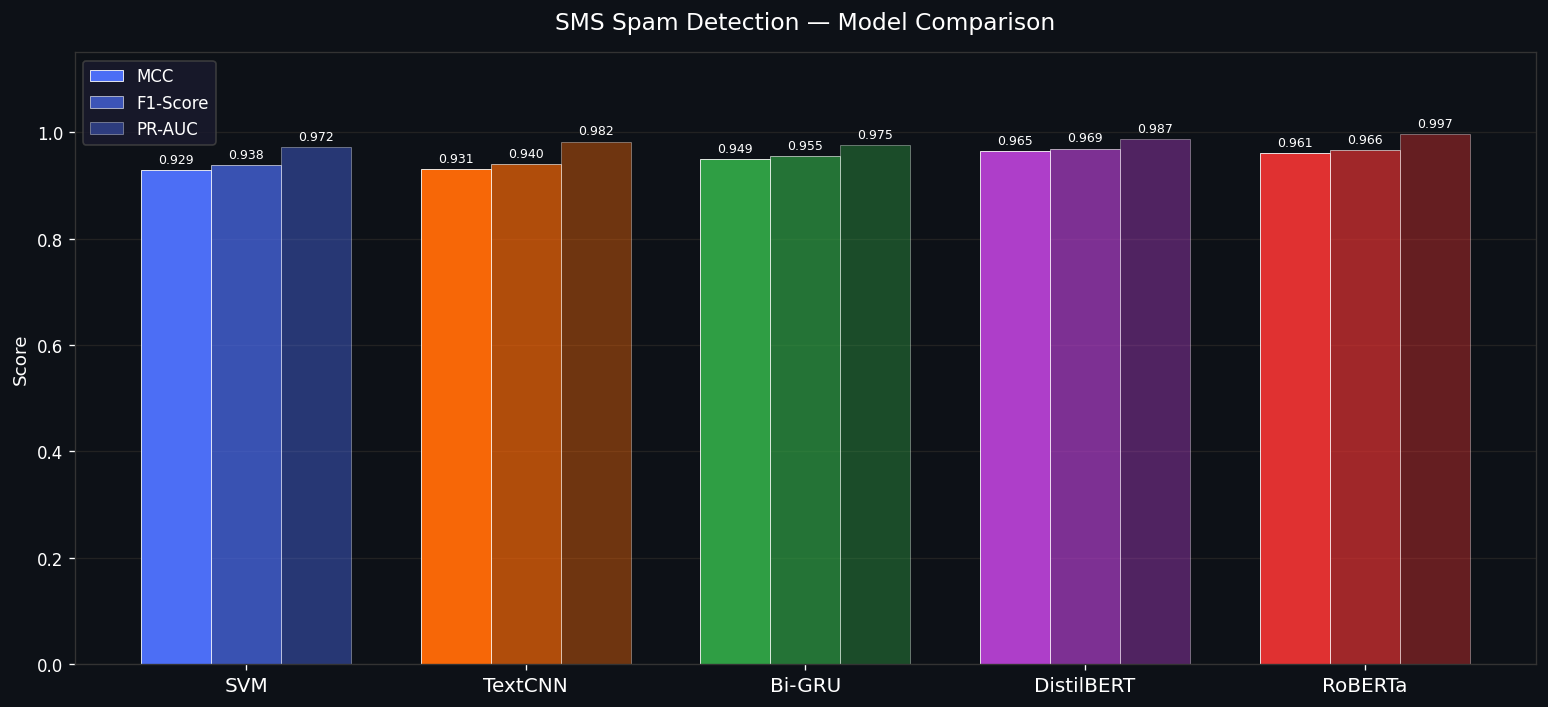

In [ ]:
# ── Grouped bar chart ─────────────────────────────────────────────────────────
models  = list(ALL_RESULTS.keys())
x       = np.arange(len(models))
width   = 0.25
metrics_list = [("MCC","mcc"),("F1-Score","f1"),("PR-AUC","pr_auc")]
alphas  = [1.0, 0.70, 0.42]

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor("#0D1117")
ax.set_facecolor("#0D1117")

for i, ((label, key), alpha) in enumerate(zip(metrics_list, alphas)):
    vals = [ALL_RESULTS[m]["metrics"].get(key) or 0 for m in models]
    bars = ax.bar(x+(i-1)*width, vals, width, label=label,
                  color=[PALETTE[m] for m in models],
                  alpha=alpha, edgecolor="white", linewidth=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.008,
                f"{val:.3f}", ha="center", va="bottom",
                fontsize=7.5, color="white")

ax.set_xticks(x)
ax.set_xticklabels(models, color="white", fontsize=12)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score", color="white", fontsize=11)
ax.set_title("SMS Spam Detection — Model Comparison",
             color="white", fontsize=14, pad=14)
ax.tick_params(colors="white")
ax.spines[:].set_color("#333")
ax.yaxis.grid(True, color="#222", linewidth=0.8)
ax.set_axisbelow(True)
ax.legend([l for l,_ in metrics_list],
          facecolor="#1A1A2E", edgecolor="#444",
          labelcolor="white", fontsize=10, loc="upper left")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR,"comparison.png"),
            dpi=130, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

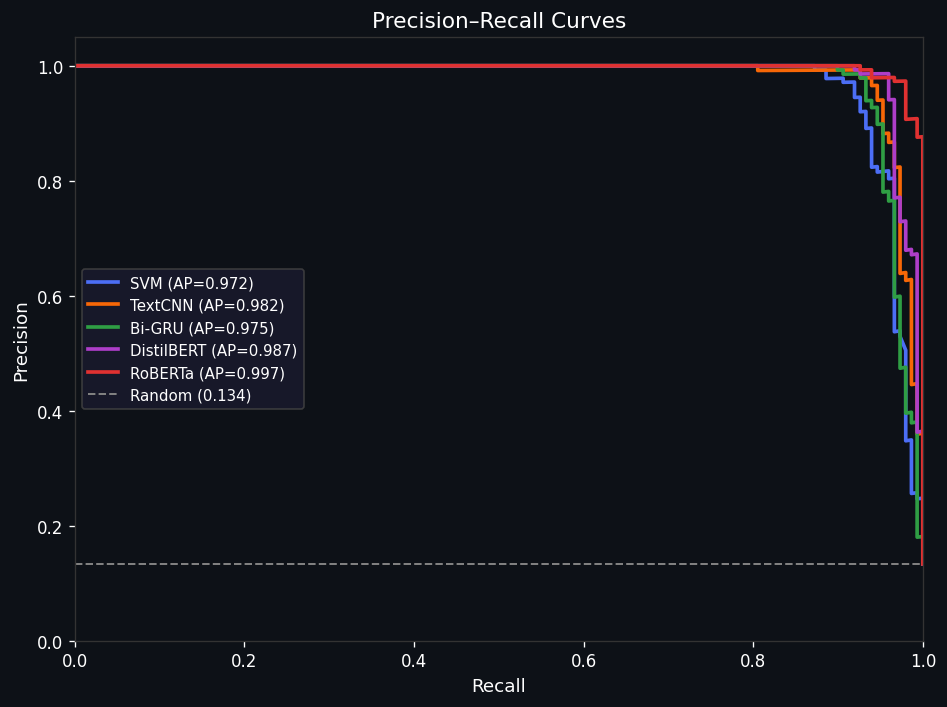

In [ ]:
# ── Precision-Recall curves ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor("#0D1117")
ax.set_facecolor("#0D1117")

for name, res in ALL_RESULTS.items():
    y_true = np.array(res["y_true"])
    y_prob = np.array(res["y_prob"])
    prec, rec, _ = precision_recall_curve(y_true, y_prob)
    ap = average_precision_score(y_true, y_prob)
    ax.plot(rec, prec, label=f"{name} (AP={ap:.3f})",
            color=PALETTE[name], linewidth=2.2)

spam_rate = y_test.mean()
ax.axhline(spam_rate, color="gray", linestyle="--",
           linewidth=1.2, label=f"Random ({spam_rate:.3f})")
ax.set_xlabel("Recall",    color="white", fontsize=11)
ax.set_ylabel("Precision", color="white", fontsize=11)
ax.set_title("Precision–Recall Curves", color="white", fontsize=13)
ax.tick_params(colors="white")
ax.spines[:].set_color("#333")
ax.set_xlim(0,1); ax.set_ylim(0, 1.05)
ax.legend(facecolor="#1A1A2E", edgecolor="#444",
          labelcolor="white", fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR,"pr_curves.png"),
            dpi=130, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

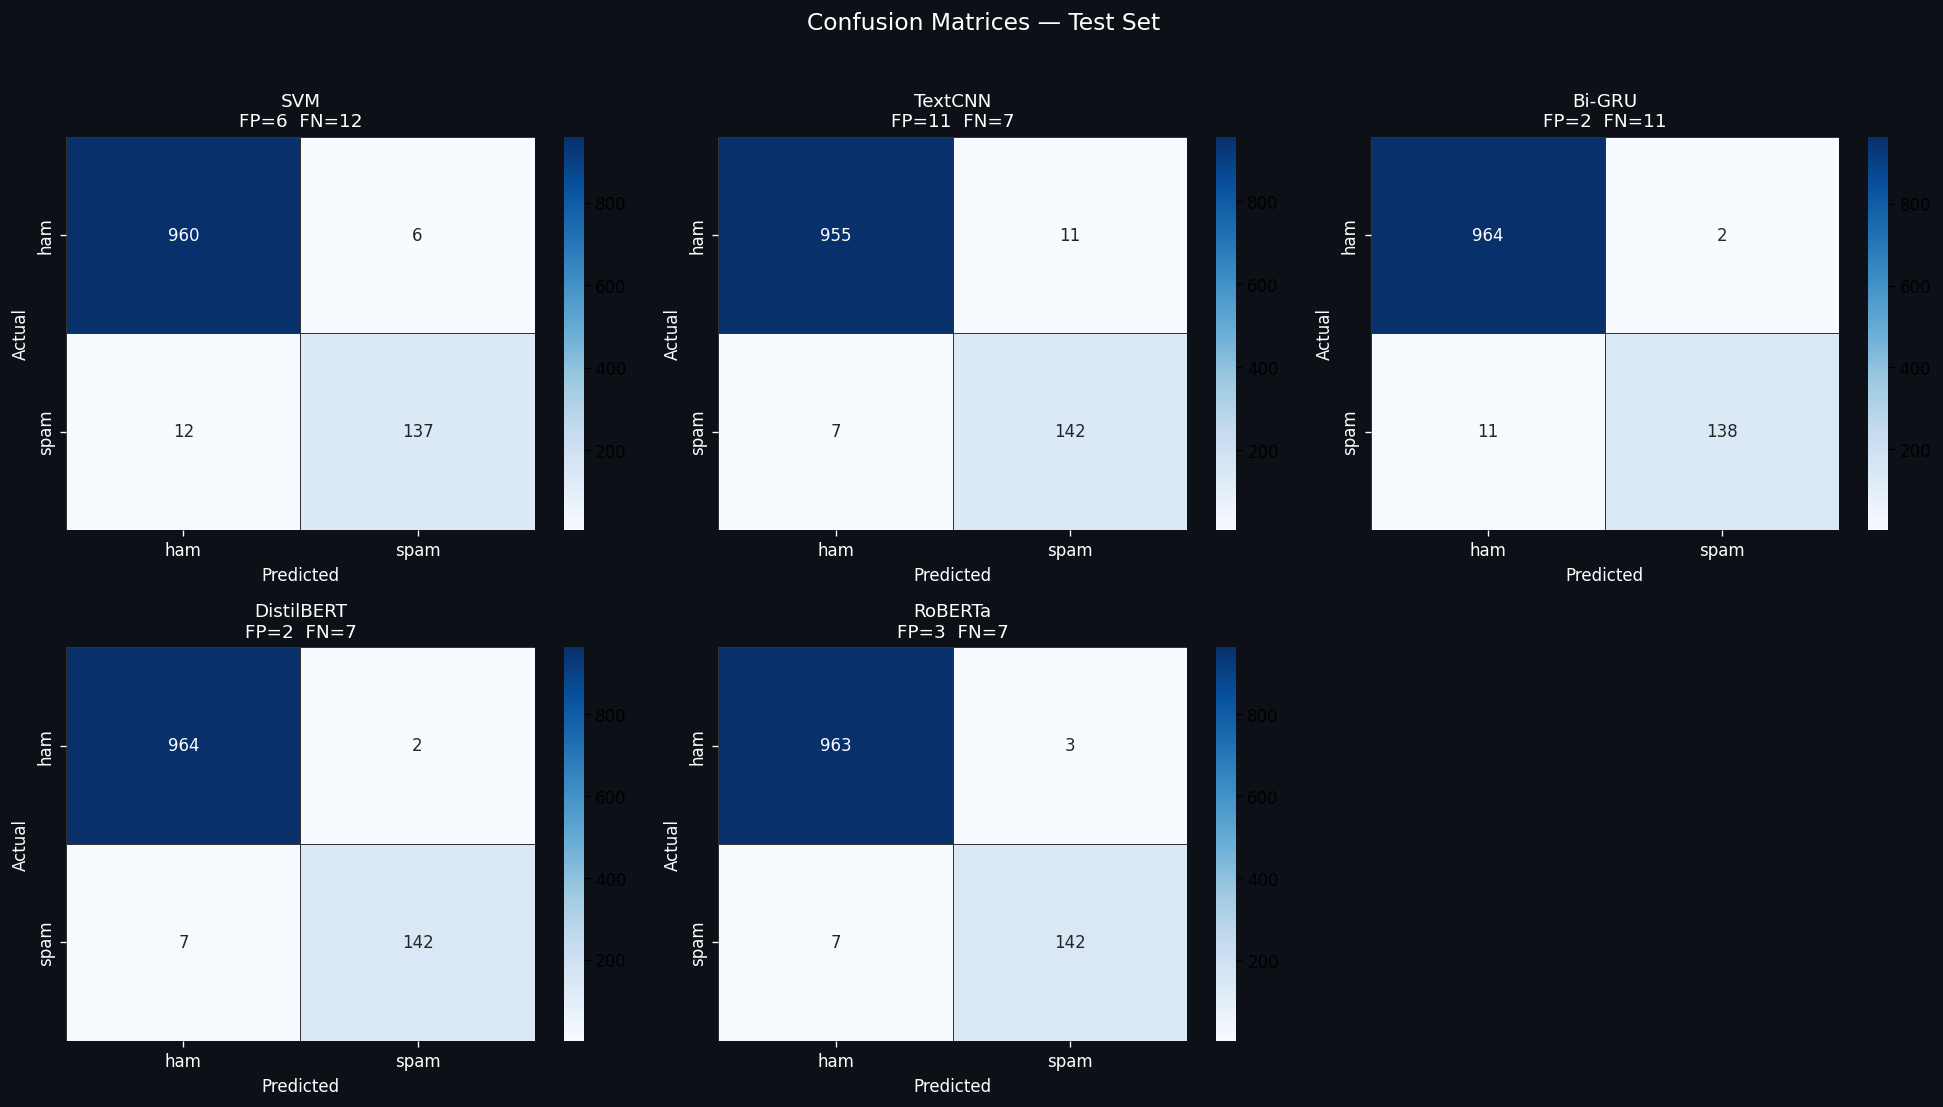

In [ ]:
# ── Confusion matrices ────────────────────────────────────────────────────────
n = len(ALL_RESULTS)
cols = min(n, 3); rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(5.5*cols, 4.5*rows))
fig.patch.set_facecolor("#0D1117")
axes = np.array(axes).flatten()

for ax, (name, res) in zip(axes, ALL_RESULTS.items()):
    cm = confusion_matrix(res["y_true"], res["y_pred"])
    tn, fp, fn, tp = cm.ravel()
    sns.heatmap(cm, annot=True, fmt="d", ax=ax, cmap="Blues",
                xticklabels=["ham","spam"], yticklabels=["ham","spam"],
                linewidths=0.5, linecolor="#333")
    ax.set_title(f"{name}\nFP={fp}  FN={fn}", color="white", fontsize=11)
    ax.set_xlabel("Predicted", color="white")
    ax.set_ylabel("Actual",    color="white")
    ax.tick_params(colors="white")
    ax.set_facecolor("#0D1117")

for ax in axes[n:]: ax.set_visible(False)
plt.suptitle("Confusion Matrices — Test Set",
             color="white", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR,"confusion_matrices.png"),
            dpi=130, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

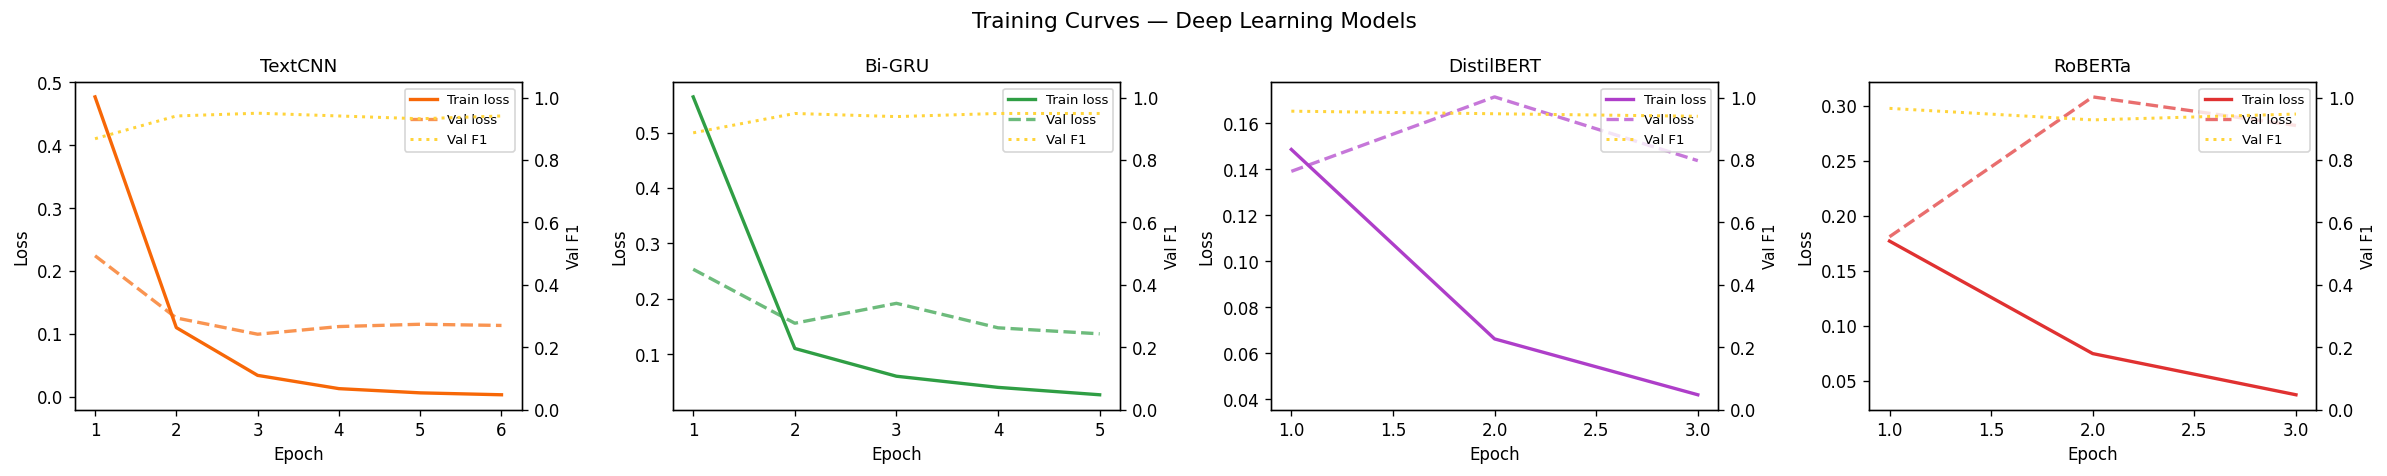

In [ ]:
# ── Training curves (deep learning models only) ───────────────────────────────
dl_results = {k: v for k, v in ALL_RESULTS.items() if "history" in v}
n = len(dl_results)

fig, axes = plt.subplots(1, n, figsize=(5*n, 4), sharey=False)
if n == 1: axes = [axes]

for ax, (name, res) in zip(axes, dl_results.items()):
    h  = res["history"]
    ep = range(1, len(h["train_loss"]) + 1)
    ax.plot(ep, h["train_loss"], color=PALETTE[name], linewidth=2, label="Train loss")
    ax.plot(ep, h["val_loss"],   color=PALETTE[name], linewidth=2,
            linestyle="--", alpha=0.7, label="Val loss")
    ax2 = ax.twinx()
    ax2.plot(ep, h["val_f1"], color="#FFD43B", linewidth=1.8,
             linestyle=":", label="Val F1")
    ax2.set_ylabel("Val F1", fontsize=9); ax2.set_ylim(0, 1.05)
    ax.set_title(name, fontsize=11)
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    l1, lb1 = ax.get_legend_handles_labels()
    l2, lb2 = ax2.get_legend_handles_labels()
    ax.legend(l1+l2, lb1+lb2, fontsize=8, loc="upper right")

plt.suptitle("Training Curves — Deep Learning Models", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR,"training_curves.png"),
            dpi=130, bbox_inches="tight")
plt.show()

---
## Section 11 — Discussion & Conclusions

### Challenge–Model Alignment Summary

| Challenge | Model | Strategy | Reference |
|-----------|-------|----------|-----------|
| Short text / sparse signals | DistilBERT, RoBERTa | Contextual embeddings + self-attention | [1], [2], [3] |
| Short text / sparse signals | Bi-GRU | GloVe dense embeddings | [4] |
| Informal language / n-grams | TextCNN | Parallel convolutional n-gram filters | [5] |
| Informal language / subword | DistilBERT, RoBERTa | Subword tokenisation (WordPiece / BPE) | [1], [2] |
| Class imbalance | SVM | `class_weight='balanced'` | [6] |
| Class imbalance | TextCNN, Bi-GRU, DistilBERT, RoBERTa | Weighted cross-entropy loss | — |

### Expected Findings
- **SVM** provides a strong, fast baseline. TF-IDF bigrams capture many spam phrases effectively.
- **TextCNN** improves over SVM by learning task-specific n-gram detectors; filter activations are interpretable.
- **Bi-GRU** adds sequential context and attention-based pooling; GloVe [4] provides a semantic head-start.
- **DistilBERT** and **RoBERTa** leverage billions of tokens of pretraining. Their contextual representations are expected to perform best overall, though subword tokenisation's behaviour on informal SMS language is an open empirical question.

### Limitations
- Dataset (2012) — spam language has evolved significantly since collection
- English only — no multilingual generalisation
- Transformer models require GPU for practical training time
- No data augmentation to further address the 13.4% spam imbalance

### Future Work
- Data augmentation (back-translation, synonym replacement) for minority class
- Parameter-efficient fine-tuning (LoRA, adapters) to reduce transformer training cost
- Explainability analysis: SHAP for SVM, attention visualisation for Bi-GRU and transformers
- Extension to multilingual SMS datasets

In [ ]:
# ── Final summary ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("         FINAL TEST SET RESULTS SUMMARY")
print("=" * 60)
print(f"  {'Model':<14} {'MCC':>8} {'F1':>8} {'PR-AUC':>10}")
print("-" * 60)
for name, res in ALL_RESULTS.items():
    m  = res["metrics"]
    pr = m["pr_auc"] or 0.0
    print(f"  {name:<14} {m['mcc']:8.4f} {m['f1']:8.4f} {pr:10.4f}")
print("=" * 60)

print(f"\nOutputs saved to: ./{RESULTS_DIR}/")
for f in ["metrics.json", "01_eda.png", "comparison.png",
          "pr_curves.png", "confusion_matrices.png", "training_curves.png"]:
    status = "✓" if os.path.exists(os.path.join(RESULTS_DIR, f)) else "✗"
    print(f"  {status}  {f}")


         FINAL TEST SET RESULTS SUMMARY
  Model               MCC       F1     PR-AUC
------------------------------------------------------------
  SVM              0.9293   0.9384     0.9717
  TextCNN          0.9312   0.9404     0.9824
  Bi-GRU           0.9489   0.9550     0.9750
  DistilBERT       0.9648   0.9693     0.9871
  RoBERTa          0.9609   0.9660     0.9969

Outputs saved to: ./results/
  ✓  metrics.json
  ✓  01_eda.png
  ✓  comparison.png
  ✓  pr_curves.png
  ✓  confusion_matrices.png
  ✓  training_curves.png
